<u>**General Notebook TODO's:**</u>
- Figure out how to fix the paths, so that we can delete unnecessary code block
- Document each process better in the vivarium ecoli process Docstrings (it will automatically update in the jupyter notebook)
- Create topology registry and load in topologies from there instead of hard coding them in for each process.
- Analyze unique molecules and create plots

<u>**Abhi TODO's:**</u>
- Finish up processes and make PR
    1. standardize doc strings in vivarium processes (pycharm)
    2. fix topology plots for each process
    3. make sure to check what field of data variable you are printing
    4. Add text (helps people read the jupyter notebook)
    5. Select a few molecules
    6. Plot all molecules globally
    7. Fix order of processes (most interesting process first!)
- Combine and run master and submit 2nd PR

<u>**Questions:**</u>
1. Which molecules to plot/present for each TF Binding, Chromosome Replication?

<u>**Miscellaneous notes/ideas:**</u>
- interactive widgets (plotly) - users can click boxes to choose which ones to plot

In [ ]:
# ONLY RUN THIS CELL ONCE!!
# TODO: Fix this

# Make sure this is running out of vivarium-ecoli directory
import sys

sys.path[0] += '/..'

# display system path
sys.path[0]

In [ ]:
from vivarium.core.store import Store
schema_keys = Store.schema_keys

# Helper functions
def make_port_printout(ports_schema, depth=0, schema_show=5, filler_size=5):
    print_dict = ''
    filler = filler_size * ' '
    for port, schema in ports_schema.items():
        if isinstance(schema, dict):
            schemavars = list(schema.keys())
            if any(var in schemavars for var in schema_keys):
                print_schema = ''
                for k, v in schema.items():
                    print_schema += f'{(depth+1) * filler} {k}: {v}\n'
                print_dict += f'{depth * filler}{port}:\n{print_schema}\n'
            else:
                schema_items = schema.items()
                first_schema = dict(list(schema_items)[:schema_show])
                next_print = make_port_printout(first_schema, depth+1)
                print_dict += f'{port}:\n{next_print}\n'
                if len(schema) > schema_show:
                    print_dict += f'{(depth+1) * filler}'
                    print_dict += f'... skipping {len(schema)-schema_show} schema entries ...'
                    print_dict += f'\n\n'
        else:
            print_dict += f'{filler}{schema}\n'
    return print_dict

def find_increasing(d):
    for key, value in d.items():
        if value[-1] > value[0]:
            return {key: value}
    
def find_decreasing(d):
    for key, value in d.items():
        if value[-1] < value[0]:
            return {key: value}

In [ ]:
# The notebook officially starts here!!

# <u>**Vivarium E. coli**<u/>

This notebook demonstrates features of the processes in the Vivarium E. coli model. First, we show distinct features of how the processes work individually. Then we combine the processes in our simulation to demonstrate how they work together. Finally, we run the entire model.

# **1. Load the required components**

To run the E. coli model, we need a few things:
 1. **sim_data**: the model parameters from wcEcoli.
 2. **initial_state**: the initial state of the system -- a snapshot from wcEcoli.

## Load sim_data

In [4]:
from ecoli.library.sim_data import LoadSimData

SIM_DATA_PATH = '../reconstruction/sim_data/kb/simData.cPickle'

load_sim_data = LoadSimData(
            sim_data_path=SIM_DATA_PATH,
            seed=0)

## Get initial state snapshot

In [5]:
from ecoli.composites.ecoli_master import get_state_from_file

INITIAL_STATE_PATH = '../data/wcecoli_t1000.json'

initial_state = get_state_from_file(path=INITIAL_STATE_PATH)

# **2. Simulate Processes Individually**


Now we can load in our modular processes individually. For each process, we will:

1. Load in the process and parameters
2. Plot a **toplogy** diagram 
    - The topology is a network that demonstrates how a process connects to its stores (which hold state variables).
3. Display the **ports schema**
     - The port schema defines a systems ports (top-level keys), and the expected behavior of molecules under that port (its *schema*)
     - `*` is a wild card, specifies the schema of everything that can go into the port
4. Simulate the process
5. Demonstrate distinct features of that process

In [6]:
from vivarium.core.process import Process
from vivarium.core.store import Store
from vivarium.core.engine import pp #, Engine
from vivarium.core.composition import simulate_process, simulate_composite
from vivarium.plots.topology import plot_topology
from vivarium.plots.simulation_output import plot_variables
import ecoli
import copy

## <u>Complexation<u/>

In [ ]:
from ecoli.processes.complexation import Complexation

# print documentation from process docstring
print(ecoli.processes.complexation.__doc__)

In [ ]:
# load in parameters
cplx_config = load_sim_data.get_complexation_config()

# initialize process and topology
complexation = Complexation(cplx_config)

cplx_topology = {
    'molecules': ('bulk',)
}

In [ ]:
# plot topology
cplx_topology_plot_settings = {
    'buffer': 1,
    'node_labels': {
        'ecoli-complexation': 'ecoli\ncomplexation'
    },
    'show_ports': False,
    'node_size': 10000,
    'dashed_edges': True
}

cplx_topology_fig = plot_topology(complexation, cplx_topology_plot_settings)

In [ ]:
# display ports schema
cplx_ports = complexation.ports_schema()
cplx_printout = make_port_printout(cplx_ports)
print(cplx_printout)

In [ ]:
# tweak initial state
cplx_initial_state = copy.deepcopy(initial_state)
cplx_initial_state['bulk']['1-PFK-MONOMER[c]'] = 100

# run simulation and retrieve final data
cplx_settings = {
    'total_time': 10,
    'initial_state': cplx_initial_state,
    'topology': cplx_topology}

cplx_data = simulate_process(complexation, cplx_settings)

print('\nsimulation output:')
pp(cplx_data['bulk'])

For complexation, let's look at the 1-PFK-MONOMER monomer as it transitions to the 1-PFK complex:

In [ ]:
# plot output
cplx_fig = plot_variables(
    cplx_data, 
    variables=[
        ('bulk', '1-PFK-MONOMER[c]'), 
        ('bulk', '1-PFK[c]'), 
    ],
    column_width=10, row_height=3, row_padding=0.5)

Here we see 1-PFK-MONOMER getting complexed. This a relatively fast process and consumes all the monomers in a single time step.

## <u>Transcript Initiation<u/>

In [ ]:
from ecoli.processes.transcript_initiation import TranscriptInitiation

# print documentation from process docstring
print(ecoli.processes.transcript_initiation.__doc__)

In [ ]:
# load in parameters
ti_params = load_sim_data.get_transcript_initiation_config()

# initialize process and topology
transcript_initiation = TranscriptInitiation(ti_params)

ti_topology = {
    'environment': ('environment',),
    'full_chromosomes': ('unique', 'full_chromosome'),
    'RNAs': ('unique', 'RNA'),
    'active_RNAPs': ('unique', 'active_RNAP'),
    'promoters': ('unique', 'promoter'),
    'molecules': ('bulk',),
    'listeners': ('listeners',)
}

In [ ]:
# plot topology
ti_topology_plot_settings = {
    'node_labels': {
        'ecoli-transcript-initiation': 'ecoli\ntranscript\ninitiation',
        'full_chromosomes': 'full\nchromosomes',
        'listeners\nrna_synth_prob': 'listeners\nrna_synth_\nprob',
        'listeners\nribosome_data': 'listeners\nribosome_\ndata',
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-transcript-initiation': (4, 2)}
}

ti_topology_fig = plot_topology(transcript_initiation, ti_topology_plot_settings)

In [ ]:
# display ports schema
ti_ports = transcript_initiation.ports_schema()
ti_printout = make_port_printout(ti_ports)
print(ti_printout)

In [ ]:
# run simulation and retrieve final data
ti_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': ti_topology}

ti_data = simulate_process(transcript_initiation, ti_settings)

print('\nsimulation output:')
pp(ti_data['unique']['active_RNAP'])

For Transcript Initiation, we can see from the cell above that each active RNA polymerase molecule is represented by an ID number. Let's analyze how one of these active RNA polymerase molecules functions within this process:

In [ ]:
# plot output

RNAP_ID = list(ti_data['unique']['active_RNAP'].keys())[0] 

ti_fig = plot_variables(
    ti_data, 
    variables=[
        ('unique', 'active_RNAP', RNAP_ID, 'coordinates'),
        ('bulk', 'APORNAP-CPLX[c]')
        ],
    column_width=10, row_height=3, row_padding=0.5)

Here we can see that the coordinates for one RNA polymerase molecule is initialized at time=0 and remains the same throughout the simulation as elongation is not a function of this process. Additionally, we can see that the RNA polymerase molecules (given by APORNAP-CPLX[c]) are getting deleted from the bulk molecules count as they bind to the DNA sequence and are initialized for transcription.

## <u>Transcript Elongation<u/>

In [ ]:
from ecoli.processes.transcript_elongation import TranscriptElongation

# print documentation from process docstring
print(ecoli.processes.transcript_elongation.__doc__)

In [ ]:
# load in parameters
te_params = load_sim_data.get_transcript_elongation_config()

# initialize process and topology
transcript_elongation = TranscriptElongation(te_params)

te_topology = {
    'environment': ('environment',),
    'RNAs': ('unique', 'RNA'),
    'active_RNAPs': ('unique', 'active_RNAP'),
    'molecules': ('bulk',),
    'bulk_RNAs': ('bulk',),
    'ntps': ('bulk',),
    'listeners': ('listeners',)
}

In [ ]:
# plot topology
te_topology_plot_settings = {
    'node_labels': {
        'ecoli-transcript-elongation': 'ecoli\ntranscript\nelongation',
        'listeners\ntranscript_elongation_listener': '\nlisteners\ntranscript_\nelongation_\nlistener'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-transcript-elongation': (4, 2)}
}

te_topology_fig = plot_topology(transcript_elongation, te_topology_plot_settings)

In [ ]:
# display ports schema
te_ports = transcript_elongation.ports_schema()
te_printout = make_port_printout(te_ports)
print(te_printout)

In [ ]:
# run simulation and retrieve final data
te_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': te_topology}

te_data = simulate_process(transcript_elongation, te_settings)

print('\nsimulation output:')
pp(te_data['unique']['active_RNAP'])

For Transcript Elongation, we can see from the cell above that each active RNA Polymerase molecule is represented by an ID number. Let's analyze how a few of these active RNA Polymerase molecules function within this process:

In [ ]:
# plot output
te_fig = plot_variables(
    te_data, 
    variables=[
        ('unique', 'active_RNAP', '1266660', 'coordinates'),
        ('unique', 'active_RNAP', '1293463', 'coordinates'),
        ('unique', 'active_RNAP', '1293466', 'coordinates')
        ],
    column_width=10, row_height=3, row_padding=0.5)

Here we can see that the coordinates for these RNA Polymerase molecules are initialized at time=0 but change throughout the simulation. Some polymerase coordinates incease, indicating elongation in one direction, and others decrease, indicating elongation in the opposite direction along the DNA sequence. 

Funadamentally, these changes represent the process of polymerization: as the RNA polymerase molecules travel across the DNA, RNA molecucles are assembled.

## <u>TF Binding<u/>

In [ ]:
from ecoli.processes.tf_binding import TfBinding

# print documentation from process docstring
print(ecoli.processes.tf_binding.__doc__)

In [ ]:
# load in parameters
tfb_params = load_sim_data.get_tf_config()

# initialize process and topology
tf_binding = TfBinding(tfb_params)

tfb_topology = {
    'promoters': ('unique', 'promoter'),
    'active_tfs': ('bulk',),
    'inactive_tfs': ('bulk',),
    'listeners': ('listeners',)
}

In [ ]:
# plot topology
tfb_topology_plot_settings = {
    'node_labels': {
        'ecoli-tf-binding': 'ecoli\ntf binding',
        'listeners\nrna_synth_prob': 'listeners\nrna_synth_\nprob',
    },
    'show_ports': False,
    'node_size': 16000,
    'node_distance': 3.5,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-tf-binding': (2, 2)}
}

tfb_topology_fig = plot_topology(tf_binding, tfb_topology_plot_settings)

In [ ]:
# display ports schema
tfb_ports = tf_binding.ports_schema()
tfb_printout = make_port_printout(tfb_ports)
print(tfb_printout)

In [ ]:
# run simulation and retrieve final data
tfb_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': tfb_topology}

tfb_data = simulate_process(tf_binding, tfb_settings)

print('\nsimulation output:')
pp(tfb_data['bulk'])

Here we can see the states of active transcription factors are dynamic

In [ ]:
# plot output
tfb_fig_active = plot_variables(
    tfb_data, 
    variables=[
        ('bulk', 'CPLX-125[c]'),
        ('bulk', 'CPLX0-226[c]'),
        ('bulk', 'MONOMER0-162[c]')
        ],
    column_width=10, row_height=3, row_padding=0.5)

## <u>Chromosome Replication<u/>

In [ ]:
from ecoli.processes.chromosome_replication import ChromosomeReplication

# print documentation from process docstring
print(ecoli.processes.chromosome_replication.__doc__)

In [ ]:
# load in parameters
cr_params = load_sim_data.get_chromosome_replication_config()

# initialize process and topology
chromosome_replication = ChromosomeReplication(cr_params)

cr_topology = {
    # bulk molecules
    'replisome_trimers': ('bulk',),
    'replisome_monomers': ('bulk',),
    'dntps': ('bulk',),
    'ppi': ('bulk',),

    # unique molecules
    'active_replisomes': ('unique', 'active_replisome',),
    'oriCs': ('unique', 'oriC',),
    'chromosome_domains': ('unique', 'chromosome_domain',),
    'full_chromosomes': ('unique', 'full_chromosome',),

    # other
    'listeners': ('listeners',),
    'environment': ('environment',),
}

In [ ]:
# plot topology
cr_topology_plot_settings = {
    'node_labels': {
        'ecoli-chromosome_replication': 'ecoli\nchromosome\nreplication',
        'replisome_trimers': 'replisome\ntrimers',
        'replisome_monomers': 'replisome\nmonomers',
        'active_replisomes': 'active\nreplisomes',
        'full_chromosomes': 'full\nchromosomes',
        'chromosome_domains': 'chromosome\ndomains',
        'listeners\nreplication_data': 'listeners\nreplication_\ndata'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.5,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-chromosome_replication': (3, 2)}
}

cr_topology_fig = plot_topology(chromosome_replication, cr_topology_plot_settings)

In [ ]:
# display ports schema
cr_ports = chromosome_replication.ports_schema()
cr_printout = make_port_printout(cr_ports)
print(cr_printout)

In [ ]:
# tweak initial state to trigger replication
cr_initial_state = copy.deepcopy(initial_state)
cr_initial_state['listeners']['mass']['cell_mass'] = 2000.0

# run simulation and retrieve final data
cr_settings = {
    'total_time': 100,
    'initial_state': cr_initial_state,
    'topology': cr_topology,
    'emit_step': 10,
    'return_raw_data': True}

cr_data = simulate_process(chromosome_replication, cr_settings)

print('\nsimulation output:')

pp(cr_data.keys())

In [ ]:
cr_data[0.0]['unique']['oriC']

In [ ]:
cr_data[10.0]['unique']['oriC']

Here a new origin of replication (oriC) has formed between time 0 and 10. This indicates the beginning of the chromosome replication process.

## <u>Polypeptide Initiation<u/>

In [ ]:
from ecoli.processes.polypeptide_initiation import PolypeptideInitiation

# print documentation from process docstring
print(ecoli.processes.polypeptide_initiation.__doc__)

In [ ]:
# load in parameters
pi_params = load_sim_data.get_polypeptide_initiation_config()

# initialize process and topology
polypeptide_initiation = PolypeptideInitiation(pi_params)

pi_topology = {
    'environment': ('environment',),
    'listeners': ('listeners',),
    'active_ribosome': ('unique', 'active_ribosome'),
    'RNA': ('unique', 'RNA'),
    'subunits': ('bulk',)
}

In [ ]:
# plot topology
pi_topology_plot_settings = {
    'node_labels': {
        'ecoli-polypeptide-initiation': 'ecoli\npolypeptide\ninitiation',
        'active_ribosome': 'active\nribosome'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.5,
    'dashed_edges': True,
    'font_size': 17,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-polypeptide-initiation': (3, 2)}
}

pi_topology_fig = plot_topology(polypeptide_initiation, pi_topology_plot_settings)

In [ ]:
# display ports schema
pi_ports = polypeptide_initiation.ports_schema()
pi_printout = make_port_printout(pi_ports)
print(pi_printout)

In [ ]:
# run simulation and retrieve final data
pi_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': pi_topology}

pi_data = simulate_process(polypeptide_initiation, pi_settings)

print('\nsimulation output:')
pp(pi_data['bulk'])

We can observe the 30S ribosomal subunit ('CPLX0-3953[c]') and 50S ribosomal subunit (CPLX0-3962[c]) molecule counts:

In [ ]:
# plot output
pi_fig = plot_variables(
    pi_data, 
    variables=[
        ('bulk', 'CPLX0-3953[c]'),
        ('bulk', 'CPLX0-3962[c]')
        ],
    column_width=10, row_height=3, row_padding=0.5)

The decrease within the first time step of the simulation demonstrates how active 70S ribosomes are rapidly formed from free 30S and 50S subunits. We can also see how the 30S ribosome subunit (CPLX0-3953[c]) is limiting.

## <u>Polypeptide Elongation<u/>

In [ ]:
from ecoli.processes.polypeptide_elongation import PolypeptideElongation

# print documentation from process docstring
print(ecoli.processes.polypeptide_elongation.__doc__)

In [ ]:
# load in parameters
pe_params = load_sim_data.get_polypeptide_elongation_config()

# initialize process and topology
polypeptide_elongation = PolypeptideElongation(pe_params)

pe_topology = {
    'environment': ('environment',),
    'listeners': ('listeners',),
    'active_ribosome': ('unique', 'active_ribosome'),
    'molecules': ('bulk',),
    'monomers': ('bulk',),
    'amino_acids': ('bulk',),
    'ppgpp_reaction_metabolites': ('bulk',),
    'uncharged_trna': ('bulk',),
    'charged_trna': ('bulk',),
    'charging_molecules': ('bulk',),
    'synthetases': ('bulk',),
    'subunits': ('bulk',),
    'polypeptide_elongation': ('process_state', 'polypeptide_elongation')
}

In [ ]:
# plot topology
pe_topology_plot_settings = {
    'node_labels': {
        'ecoli-polypeptide-elongation': 'ecoli\npolypeptide\nelongation',
        'uncharged_trna': 'uncharged_\ntrna',
        'charging_molecules': 'charging_\nmolecules',
        'active_ribosome': 'active_\nribosome',
        'polypeptide_elongation': 'polypeptide\nelongation',
        'ppgpp_reaction_metabolites': 'ppgpp\nreaction\nmetabolites',
        'chromosome_domains': 'chromosome\ndomains',
        'listeners\nreplication_data': 'listeners\nreplication_\ndata'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 17,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-polypeptide-elongation': (7, 1.75)}
}

pe_topology_fig = plot_topology(polypeptide_elongation, pe_topology_plot_settings)

In [ ]:
# display ports schema
pe_ports = polypeptide_elongation.ports_schema()
pe_printout = make_port_printout(pe_ports)
print(pe_printout)

In [ ]:
# run simulation and retrieve final data
pe_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': pe_topology}

pe_data = simulate_process(polypeptide_elongation, pe_settings)

print('\nsimulation output:')
pp(pe_data['unique']['active_ribosome'])

We can see from the cell above that each active ribosome molecule is represented by an ID number. Let's analyze the polypeptide length and the ribosome's position on mRNA of one active ribosome within this process:

In [ ]:
# plot output

RIBOSOME_ID = list(pe_data['unique']['active_ribosome'].keys())[0]

pe_fig = plot_variables(
    pe_data, 
    variables=[
        ('unique', 'active_ribosome', RIBOSOME_ID, 'pos_on_mRNA'),
        ('unique', 'active_ribosome', RIBOSOME_ID, 'peptide_length'),
        ('unique', 'active_ribosome', RIBOSOME_ID, 'submass', 'protein')
        ],
    column_width=10, row_height=3, row_padding=0.5)

Here we can see that as the simulation progresses, the ribosome travels along the mRNA strand (as shown by the increasing pos_on_mRNA variable) and polymerization of amino acids into a polypeptide occurs (as shown by the increasing peptide_length and protein submass variables).

After elongation terminates, we can see an increase in protein counts:

In [ ]:
pe_fig1 = plot_variables(
    pe_data, 
    variables=[
        ('bulk', '6PGLUCONDEHYDROG-MONOMER[c]'),
        ('bulk', '6PGLUCONOLACT-MONOMER[c]')
    ],
    column_width=10, row_height=3, row_padding=0.5)

## <u>Protein Degradation<u/>

In [7]:
from ecoli.processes.protein_degradation import ProteinDegradation

# print documentation from process docstring
print(ecoli.processes.protein_degradation.__doc__)


Protein Degradation

Protein degradation sub-model.

This process accounts for the degradation of protein monomers.
Speciﬁc proteins to be degraded are selected as a Poisson process.



In [8]:
# load in parameters
pd_params = load_sim_data.get_protein_degradation_config()

# initialize process and topology
protein_degradation = ProteinDegradation(pd_params)

pd_topology = {
    'metabolites': ('bulk',),
    'proteins': ('bulk',)
}

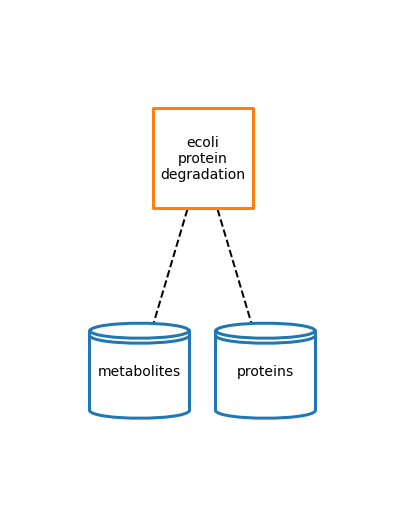

In [9]:
# plot topology
pd_topology_plot_settings = {
    'buffer': 1,
    'node_labels': {
        'ecoli-protein-degradation': 'ecoli\nprotein\ndegradation'
    },
    'node_distance': 5,
    'show_ports': False,
    'node_size': 10000,
    'dashed_edges': True,
    'coordinates': {'ecoli-protein-degradation': (1.5, 0.5)}
}

pd_topology_fig = plot_topology(protein_degradation, pd_topology_plot_settings)

In [10]:
# display ports schema
pd_ports = protein_degradation.ports_schema()
pd_printout = make_port_printout(pd_ports)
print(pd_printout)

metabolites:
     L-ALPHA-ALANINE[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     ARG[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     ASN[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     L-ASPARTATE[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     CYS[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True


     ... skipping 17 schema entries ...

proteins:
     1-ACYLGLYCEROL-3-P-ACYLTRANSFER-MONOMER[i]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     1-PFK-MONOMER[c]:
           _default: 0
           _divider: binomial
           _properties: {'bul

In [12]:
# run simulation and retrieve final data
pd_settings = {
    'total_time': 600,
    'initial_state': initial_state,
    'topology': pd_topology,
    'emit_step': 10}

pd_data = simulate_process(protein_degradation, pd_settings)

#print('\nsimulation output:')
#pp(pd_data['bulk'])


Simulation ID: 7c630404-0214-11ec-8f11-3c15c2dc0586
Created: 08/20/2021 at 17:12:35
Completed in 11.26 seconds


For protein degradation, let's look at the ARTJ-MONOMER[p] monomer, a protein selected for degradation at this time point, as it degrades into its subcomponents:

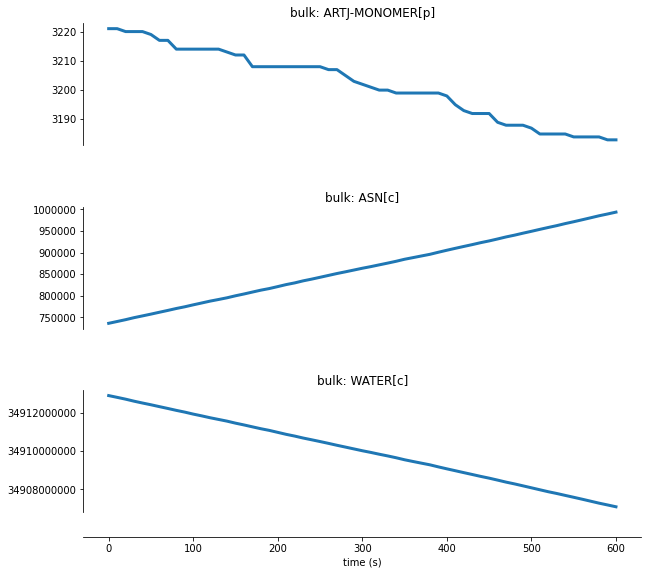

In [13]:
# plot output
pd_fig = plot_variables(
    pd_data, 
    variables=[
        ('bulk', 'ARTJ-MONOMER[p]'),
        ('bulk', 'ASN[c]'),
        ('bulk', 'WATER[c]')
        ],
    column_width=10, row_height=3, row_padding=0.5)

We can see here that as the ARTJ-MONOMER[p] protein degrades, the count for the amino acid asparagine increases and water is consumed.

## <u>RNA Degradation<u/>

In [41]:
from ecoli.processes.rna_degradation import RnaDegradation

# print documentation from process docstring
print(ecoli.processes.rna_degradation.__doc__)


RNA Degradation

Submodel for RNA degradation.

Mathematical formulation:

dr/dt = Kb - Kd * r
or,

dr/dt = Kb - kcatEndoRNase * EndoRNase * r / (Km + r)
or,

dr/dt = Kb - kcatEndoRNase * EndoRNase * r/Km / (1 + Sum(r/Km))

    where   r = RNA counts
            Kb = RNA production given a RNAP synthesis rate 
            tau = doubling time
            kcatEndoRNase = enzymatic activity for EndoRNases
            kd = RNA degradation rates 
            Km = Michaelis-Menten constants fitted to recapitulate first-order
            RNA decay:
                kd * r = kcatEndoRNase * EndoRNase * r / (Km + r),
                    non-cooperative EndoRNases
                kd * r = kcatEndoRNase * EndoRNase * r/Km / (1 + sum(r/Km)),
                    cooperation

This sub-model encodes molecular simulation of RNA degradation as two main
steps guided by RNases, "endonucleolytic cleavage" and "exonucleolytic
digestion":

1. Compute total counts of RNA to be degraded (D) and total capacity

In [42]:
# load in parameters
rd_params = load_sim_data.get_rna_degradation_config()

# rd_params['_schema'] = {
#     'RNAs': {
#         '*': {
#             'can_translate': {
#                 '_emit': True
#             },
#             'is_full_transcript': {
#                 '_emit': True
#             }
#         }
#     }
# }

# initialize process and topology
rna_degradation = RnaDegradation(rd_params)

rd_topology = {
    'charged_trna': ('bulk',),
    'bulk_RNAs': ('bulk',),
    'nmps': ('bulk',),
    'fragmentMetabolites': ('bulk',),
    'fragmentBases': ('bulk',),
    'endoRnases': ('bulk',),
    'exoRnases': ('bulk',),
    'subunits': ('bulk',),
    'molecules': ('bulk',),
    'RNAs': ('unique', 'RNA'),
    'active_ribosome': ('unique', 'active_ribosome'),
    'listeners': ('listeners',)
}

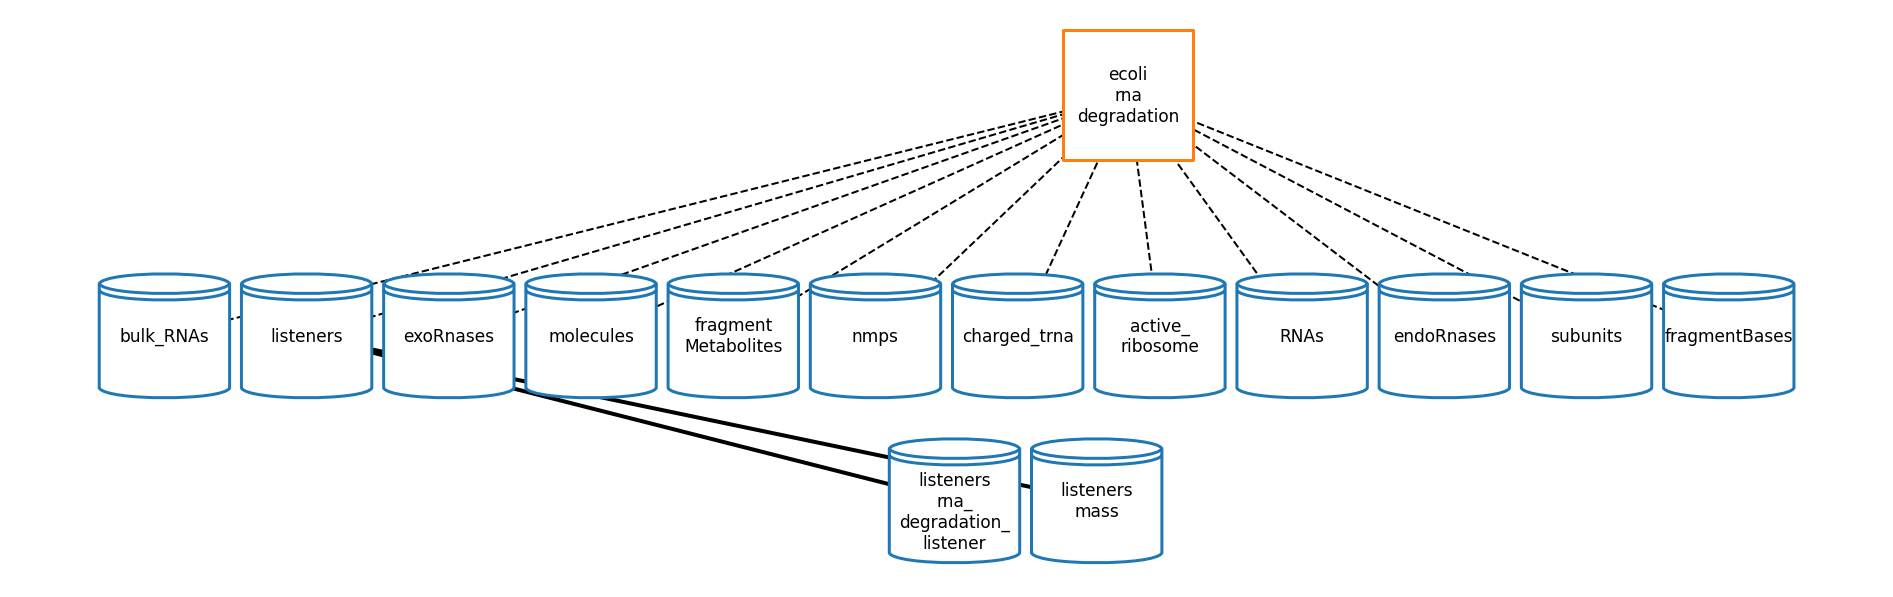

In [43]:
# plot topology
rd_topology_plot_settings = {
    'node_labels': {
        'ecoli-rna-degradation': 'ecoli\nrna\ndegradation',
        'fragmentMetabolites': 'fragment\nMetabolites',
        'listeners\nrna_degradation_listener': '\nlisteners\nrna_\ndegradation_\nlistener',
        'active_ribosome': 'active_\nribosome'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 17,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-rna-degradation': (7, 1.75)}
}

rd_topology_fig = plot_topology(rna_degradation, rd_topology_plot_settings)

In [25]:
# display ports schema
rd_ports = rna_degradation.ports_schema()
rd_printout = make_port_printout(rd_ports)
print(rd_printout)

charged_trna:
     charged-alaT-tRNA[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     charged-alaU-tRNA[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     charged-alaV-tRNA[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     charged-alaW-tRNA[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     charged-alaX-tRNA[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True


     ... skipping 81 schema entries ...

bulk_RNAs:
     EG10001_RNA[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True
           _updater: nonnegative_accumulate

     EG10002_RNA[c]:
           _defa

In [55]:
# run simulation and retrieve final data
rd_settings = {
    'total_time': 100,
    'initial_state': initial_state,
    'topology': rd_topology}

rd_data = simulate_process(rna_degradation, rd_settings)

print('\nsimulation output:')

#pp(rd_data['bulk'])


Simulation ID: 24819d88-0217-11ec-8f11-3c15c2dc0586
Created: 08/20/2021 at 17:31:38
Completed in 36.13 seconds

simulation output:


In [57]:
pp(rd_data.keys())

dict_keys(['bulk', 'unique', 'listeners', 'time'])


In [58]:
RNA_ids = rna_degradation.rnaIds

# for idx in RNA_ids:
#     if (rd_data['bulk'][idx][0] > 0):
#         print(idx)

rd_data['bulk']['RNA0-300[c]']

[23,
 23,
 22,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 21,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20,
 20]

In [59]:
rd_data['bulk']['WATER[c]']

[34912886892,
 34912886892,
 34912824471,
 34912736796,
 34912620921,
 34912481738,
 34912318848,
 34912134322,
 34911920763,
 34911686867,
 34911436201,
 34911165701,
 34910869741,
 34910551355,
 34910210835,
 34909853189,
 34909481689,
 34909110189,
 34908738689,
 34908367189,
 34907995689,
 34907624189,
 34907252689,
 34906881189,
 34906509689,
 34906138189,
 34905766689,
 34905395189,
 34905023689,
 34904652189,
 34904280689,
 34903909189,
 34903537689,
 34903166189,
 34902794689,
 34902423189,
 34902051689,
 34901680189,
 34901308689,
 34900937189,
 34900565689,
 34900194189,
 34899822689,
 34899451189,
 34899079689,
 34898708189,
 34898336689,
 34897965189,
 34897593689,
 34897222189,
 34896850689]

In [ ]:
endoRNases_ids = rna_degradation.endoRnasesIds

In [ ]:
exoRNases_ids = rna_degradation.endoRnasesIds

In [38]:
RNA_counts = count_RNAs(rd_data)
print(RNA_counts)

[7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984, 7984]


In [39]:
pp(rd_data.keys())

dict_keys([0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 16.0, 18.0, 20.0, 22.0, 24.0, 26.0, 28.0, 30.0, 32.0, 34.0, 36.0, 38.0, 40.0, 42.0, 44.0, 46.0, 48.0, 50.0, 52.0, 54.0, 56.0, 58.0, 60.0, 62.0, 64.0, 66.0, 68.0, 70.0, 72.0, 74.0, 76.0, 78.0, 80.0, 82.0, 84.0, 86.0, 88.0, 90.0, 92.0, 94.0, 96.0, 98.0, 100.0])


In [28]:
pp(rd_data['unique'].keys())

dict_keys(['active_ribosome', 'RNA'])


In [29]:
pp(rd_data['unique']['RNA'])

{ '10002': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '10006': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '10011': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '1002714': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1002715': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1002717': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1002721': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True

  '10187': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '10188': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '10194': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '10196': { 'can_translate': [True, True, True, True, True, True],
             'is_full_transcript': [True, True, True, True, True, True]},
  '1019837': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1019841': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1019854': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, Tr

               'is_full_transcript': [True, True, True, True, True, True]},
  '1025680': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1025681': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1025682': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1025684': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1025719': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1025720': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1025723': { 'can_translate': [True, True, Tru

               'is_full_transcript': [True, True, True, True, True, True]},
  '1034262': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1034267': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1034268': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1034272': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1034273': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1034274': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1034275': { 'can_translate': [True, True, Tru

  '1045818': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1045819': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1045820': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1045821': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1045858': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1045859': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True, True, True, True]},
  '1045861': { 'can_translate': [True, True, True, True, True, True],
               'is_full_transcript': [True, True, True

...

  '959628': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '959629': { 'can_translate': [True, True, True, False, False, False],
              'is_full_transcript': [True, True, True, True, True, True]},
  '959630': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '959632': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '959659': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '959660': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '959667': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, Tru

  '971150': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '971190': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '971191': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '9730': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9733': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '97365': { 'can_translate': [False, False, False, False, False, False],
             'is_full_transcript': [True, True, True, True, True, True]},
  '9737': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},


              'is_full_transcript': [True, True, True, True, True, True]},
  '976560': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '9769': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9771': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9772': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9780': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9782': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9792': { 'can_translate': [True, True, True, True, True, True],
            'i

  '985784': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '985786': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '985787': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '985797': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '985798': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '985800': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '985801': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, 

  '994096': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '994097': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '994098': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '994100': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '994101': { 'can_translate': [True, True, True, True, True, True],
              'is_full_transcript': [True, True, True, True, True, True]},
  '9953': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},
  '9954': { 'can_translate': [True, True, True, True, True, True],
            'is_full_transcript': [True, True, True, True, True, True]},


In [30]:
pp(rd_data['listeners'])

{ 'mass': {},
  'rna_degradation_listener': { 'count_rna_degraded': [ 0,
                                                        [ 0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
            

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

...

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          1,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                                                          0,
                        

In [ ]:
# Which bulk molecules are endoRNases/exoRNases?

In [ ]:
# # plot output
# rd_fig = plot_variables(
#     rd_data, 
#     variables=[
#         ],
#     column_width=10, row_height=3, row_padding=0.5)

RNAs are selected and degraded by endoRNases, and non-functional RNA fragments are digested through exoRNases. During the process water is consumed, and nucleotides, pyrophosphate and protons are released.

## <u>Two Component System<u/>

In [ ]:
from ecoli.processes.two_component_system import TwoComponentSystem

# print documentation from process docstring
print(ecoli.processes.two_component_system.__doc__)

In [ ]:
# load in parameters
tcs_params = load_sim_data.get_two_component_system_config()
    
# initialize process and topology
two_component_system = TwoComponentSystem(tcs_params)

tcs_topology = {
    'listeners': ('listeners',),
    'molecules': ('bulk',)
}

In [ ]:
# plot topology
tcs_topology_plot_settings = {
    'node_labels': {
        'ecoli-two-component-system': 'ecoli two\ncomponent\nsystem'
    },
    'show_ports': False,
    'node_size': 16000,
    'node_distance': 5.0,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-two-component-system': (1.35, 1)}
}

tcs_topology_fig = plot_topology(two_component_system, tcs_topology_plot_settings)

In [ ]:
# display ports schema
tcs_ports = two_component_system.ports_schema()
tcs_printout = make_port_printout(tcs_ports)
print(tcs_printout)

In [ ]:
# tweak initial state??
tcs_initial_state = copy.deepcopy(initial_state)

# run simulation and retrieve final data
tcs_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': tcs_topology}

tcs_data = simulate_process(two_component_system, tcs_settings)

print('\nsimulation output:')
pp(tcs_data['bulk'])

Phosphate groups are transferred from histidine kinases to response regulators and back in response to counts of ligand stimulants

In [ ]:
# # plot output
# tcs_fig = plot_variables(
#     tcs_data, 
#     variables=[
#         ],
#     column_width=10, row_height=3, row_padding=0.5)

## <u>Equilibrium<u/>

In [ ]:
from ecoli.processes.equilibrium import Equilibrium

# Print documentation from process docstring
print(ecoli.processes.equilibrium.__doc__)

In [ ]:
# load in parameters
eq_params = load_sim_data.get_equilibrium_config()

# initialize process and topology
equilibrium = Equilibrium(eq_params)

eq_topology = {
    'listeners': ('listeners',),
    'molecules': ('bulk',)
}

In [ ]:
# plot topology
eq_topology_plot_settings = {
    'node_labels': {
        'ecoli-equilibrium': 'ecoli\nequilibrium',
        'listeners\nequilibrium_listener': '\nlisteners\nequilibrium\nlistener'
    },
    'show_ports': False,
    'node_size': 14000,
    'node_distance': 5.0,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-equilibrium': (1.5, 1.25)}
}

eq_topology_fig = plot_topology(equilibrium, eq_topology_plot_settings)

In [ ]:
# display ports schema
eq_ports = equilibrium.ports_schema()
eq_printout = make_port_printout(eq_ports)
print(eq_printout)

In [ ]:
# run simulation and retrieve final data
eq_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': eq_topology}

eq_data = simulate_process(equilibrium, eq_settings)

print('\nsimulation output:')
pp(eq_data['bulk'])

In [ ]:
'APS[c]'
'ARG[c]'
'ACETOACETYL-COA[c]'
'MONOMER0-155[c]'

# # plot output
# eq_fig = plot_variables(
#     eq_data, 
#     variables=[
#         ],
#     column_width=10, row_height=3, row_padding=0.5)

## <u>Metabolism<u/>

In [60]:
from ecoli.processes.metabolism import Metabolism

# print documentation from process docstring
print(ecoli.processes.metabolism.__doc__)


Metabolism

Metabolism sub-model. Encodes molecular simulation of microbial metabolism using flux-balance analysis.

This process demonstrates how metabolites are taken up from the environment
and converted into other metabolites for use in other processes.



In [61]:
# load in parameters
meta_params = load_sim_data.get_metabolism_config()

# initialize process and topology
metabolism = Metabolism(meta_params)

meta_topology = {
    'metabolites': ('bulk',),
    'catalysts': ('bulk',),
    'kinetics_enzymes': ('bulk',),
    'kinetics_substrates': ('bulk',),
    'amino_acids': ('bulk',),
    'listeners': ('listeners',),
    'environment': ('environment',),
    'polypeptide_elongation': ('process_state', 'polypeptide_elongation')
}

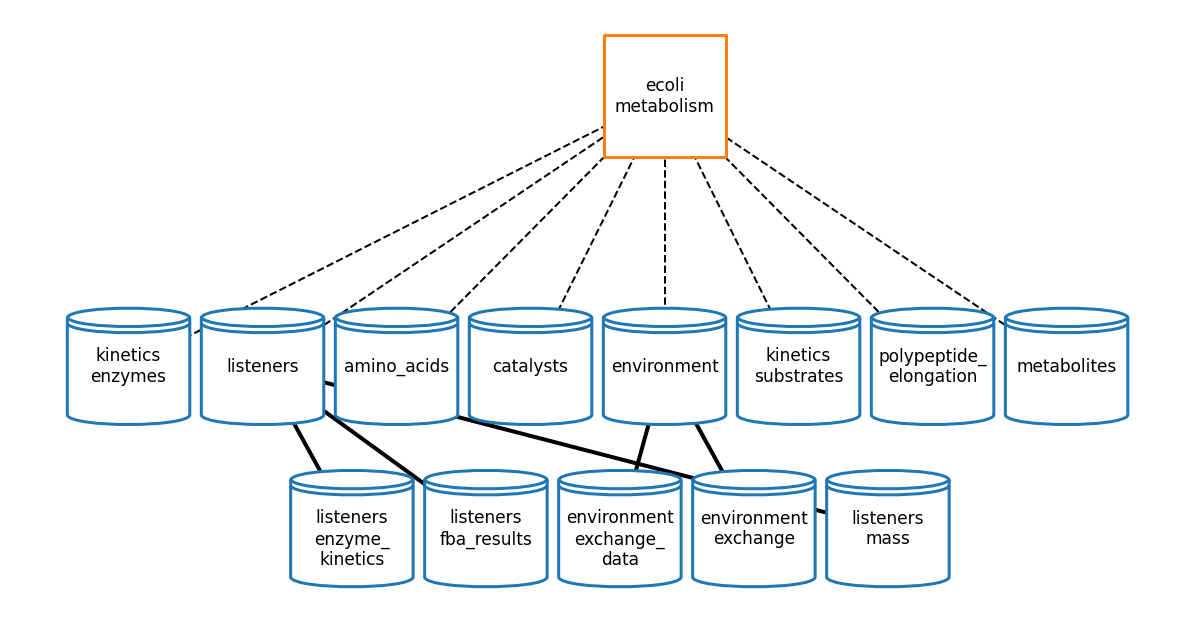

In [62]:
# plot topology
meta_topology_plot_settings = {
    'node_labels': {
        'ecoli-metabolism': 'ecoli\nmetabolism',
        'kinetics_enzymes': 'kinetics\nenzymes',
        'kinetics_substrates': 'kinetics\nsubstrates',
        'environment\nexchange_data': '\nenvironment\nexchange_\ndata',
        'listeners\nenzyme_kinetics': '\nlisteners\nenzyme_\nkinetics',
        'polypeptide_elongation': 'polypeptide_\nelongation'
    },
    'show_ports': False,
    'node_size': 15000,
    'node_distance': 3.2,
    'dashed_edges': True,
    'font_size': 17,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-metabolism': (4.5, 2)}
}

meta_topology_fig = plot_topology(metabolism, meta_topology_plot_settings)

In [63]:
# display ports schema
meta_ports = metabolism.ports_schema()
meta_printout = make_port_printout(meta_ports)
print(meta_printout)

metabolites:
     2-3-DIHYDROXYBENZOATE[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     2-KETOGLUTARATE[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     2-PG[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     2K-4CH3-PENTANOATE[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     4-AMINO-BUTYRATE[c]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True


     ... skipping 167 schema entries ...

catalysts:
     1-ACYLGLYCEROL-3-P-ACYLTRANSFER-MONOMER[i]:
           _default: 0
           _divider: binomial
           _properties: {'bulk': True}
           _emit: True

     1-PFK[c]:
           _default: 0
           _divider: binom

In [64]:
# run simulation and retrieve final data
meta_settings = {
    'total_time': 10,
    'initial_state': initial_state,
    'topology': meta_topology}

meta_data = simulate_process(metabolism, meta_settings)

print('\nsimulation output:')
pp(meta_data['bulk'])


Simulation ID: 7e7a30ca-0217-11ec-8f11-3c15c2dc0586
Created: 08/20/2021 at 17:34:07
Completed in 5.61 seconds

simulation output:
{ '1-ACYLGLYCEROL-3-P-ACYLTRANSFER-MONOMER[i]': [129, 129, 129, 129, 129, 129],
  '1-PFK[c]': [31, 31, 31, 31, 31, 31],
  '2-3-DIHYDROXYBENZOATE[c]': [112722, 112776, 112776, 112776, 112776, 112776],
  '2-DEHYDROPANTOATE-REDUCT-MONOMER[c]': [245, 245, 245, 245, 245, 245],
  '2-ISOPROPYLMALATESYN-MONOMER[c]': [1604, 1604, 1604, 1604, 1604, 1604],
  '2-KETOGLUTARATE[c]': [288340, 288477, 288477, 288477, 288477, 288477],
  '2-OCTAPRENYL-METHOXY-BENZOQ-METH-MONOMER[c]': [702, 702, 702, 702, 702, 702],
  '2-PG[c]': [74984, 75020, 75021, 75021, 75021, 75021],
  '2K-4CH3-PENTANOATE[c]': [112721, 112776, 112776, 112776, 112776, 112776],
  '2OXOGLUTARATEDEH-CPLX[c]': [102, 102, 102, 102, 102, 102],
  '3-ISOPROPYLMALDEHYDROG-CPLX[c]': [1590, 1590, 1590, 1590, 1590, 1590],
  '3-ISOPROPYLMALISOM-CPLX[c]': [3474, 3474, 3474, 3474, 3474, 3474],
  '3-METHYL-2-OXOBUT-OHCH3

  'CPLX0-821[c]': [0, 0, 0, 0, 0, 0],
  'CPLX0-8231[c]': [129, 129, 129, 129, 129, 129],
  'CPLX0-8232[c]': [3, 3, 3, 3, 3, 3],
  'CPLX0-8233[c]': [1, 1, 1, 1, 1, 1],
  'CPLX0-8238[i]': [2, 2, 2, 2, 2, 2],
  'CPLX0-8247[i]': [193, 193, 193, 193, 193, 193],
  'CPLX0-8249[c]': [53, 53, 53, 53, 53, 53],
  'CPLX0-8251[c]': [149, 149, 149, 149, 149, 149],
  'CPLX0-8252[p]': [513, 513, 513, 513, 513, 513],
  'CPLX0-8254[p]': [179, 179, 179, 179, 179, 179],
  'CPLX0-8260[c]': [64, 64, 64, 64, 64, 64],
  'CPLX0-8261[c]': [223, 223, 223, 223, 223, 223],
  'CPLX0-8262[c]': [129, 129, 129, 129, 129, 129],
  'CPLX0-8263[i]': [9, 9, 9, 9, 9, 9],
  'CPLX0-8270[p]': [33, 33, 33, 33, 33, 33],
  'CPLX0-8271[i]': [161, 161, 161, 161, 161, 161],
  'CPLX0-8280[c]': [51, 51, 51, 51, 51, 51],
  'CPLX0-8288[i]': [26, 26, 26, 26, 26, 26],
  'CPLX0-8290[c]': [2, 2, 2, 2, 2, 2],
  'CPLX0-8292[c]': [7, 7, 7, 7, 7, 7],
  'CPLX0-8299[c]': [573, 573, 573, 573, 573, 573],
  'CPLX0-8303[c]': [1, 1, 1, 1, 1, 1],
  'CP

  'EG11486-MONOMER[i]': [18, 18, 18, 18, 18, 18],
  'EG11494-MONOMER[i]': [82, 82, 82, 82, 82, 82],
  'EG11497-MONOMER[c]': [705, 705, 705, 705, 705, 705],
  'EG11498-MONOMER[c]': [19, 19, 19, 19, 19, 19],
  'EG11503-MONOMER[c]': [47, 47, 47, 47, 47, 47],
  'EG11507-MONOMER[c]': [400, 400, 400, 400, 400, 400],
  'EG11512-MONOMER[i]': [93, 93, 93, 93, 93, 93],
  'EG11538-MONOMER[c]': [62, 62, 62, 62, 62, 62],
  'EG11551-MONOMER[c]': [10, 10, 10, 10, 10, 10],
  'EG11579-MONOMER[c]': [24, 24, 24, 24, 24, 24],
  'EG11581-MONOMER[c]': [2218, 2218, 2218, 2218, 2218, 2218],
  'EG11591-MONOMER[c]': [366, 366, 366, 366, 366, 366],
  'EG11595-MONOMER[c]': [61, 61, 61, 61, 61, 61],
  'EG11600-MONOMER[c]': [349, 349, 349, 349, 349, 349],
  'EG11603-MONOMER[c]': [89, 89, 89, 89, 89, 89],
  'EG11613-MONOMER[i]': [8, 8, 8, 8, 8, 8],
  'EG11639-MONOMER[i]': [116, 116, 116, 116, 116, 116],
  'EG11646-MONOMER[c]': [1, 1, 1, 1, 1, 1],
  'EG11662-MONOMER[c]': [9, 9, 9, 9, 9, 9],
  'EG11665-MONOMER[i]': [1

  'LAUROYLACYLTRAN-MONOMER[m]': [161, 161, 161, 161, 161, 161],
  'LCTP-MONOMER[i]': [57, 57, 57, 57, 57, 57],
  'LDC2-CPLX[c]': [2, 2, 2, 2, 2, 2],
  'LEU[c]': [253325, 253325, 253325, 253326, 253326, 253327],
  'LL-DIAMINOPIMELATE[c]': [88217, 88259, 88260, 88260, 88260, 88260],
  'LSERINEDEAM1-MONOMER[c]': [219, 219, 219, 219, 219, 219],
  'LSERINEDEAM2-MONOMER[c]': [43, 43, 43, 43, 43, 43],
  'LTAA-CPLX[c]': [101, 101, 101, 101, 101, 101],
  'LTARTDEHYDRA-CPLX[c]': [2, 2, 2, 2, 2, 2],
  'LUMAZINESYN-CPLX[c]': [24, 24, 24, 24, 24, 24],
  'LYSDECARBOX-CPLX[c]': [1, 1, 1, 1, 1, 1],
  'LYSP-MONOMER[i]': [563, 563, 563, 563, 563, 563],
  'LYSU-CPLX[c]': [151, 151, 151, 151, 151, 151],
  'LYS[c]': [876953, 876953, 876953, 876953, 876953, 876953],
  'LYXK-CPLX[c]': [1, 1, 1, 1, 1, 1],
  'MALATE-DEHASE[m]': [6162, 6162, 6162, 6162, 6162, 6162],
  'MALATE-SYNTHASE[c]': [2729, 2729, 2729, 2729, 2729, 2729],
  'MALDEXPHOSPHORYL-CPLX[c]': [109, 109, 109, 109, 109, 109],
  'MALIC-NAD-CPLX[c]': 

  'THIOREDOXIN-REDUCT-NADPH-CPLX[c]': [930, 930, 930, 930, 930, 930],
  'THREDEHYDCAT-CPLX[c]': [0, 0, 0, 0, 0, 0],
  'THREDEHYDSYN-CPLX[c]': [40, 40, 40, 40, 40, 40],
  'THREO-DS-ISO-CITRATE[c]': [222054, 222160, 222160, 222160, 222160, 222160],
  'THREODEHYD-CPLX[c]': [33, 33, 33, 33, 33, 33],
  'THRESYN-MONOMER[c]': [3030, 3030, 3030, 3030, 3030, 3030],
  'THR[c]': [1346987, 1346987, 1346987, 1346987, 1346987, 1346987],
  'THYMIDYLATESYN-CPLX[c]': [415, 415, 415, 415, 415, 415],
  'TMAOREDUCTI-CPLX[p]': [3, 3, 3, 3, 3, 3],
  'TNAB-MONOMER[i]': [11, 11, 11, 11, 11, 11],
  'TORA-MONOMER[p]': [10, 10, 10, 10, 10, 10],
  'TPI[c]': [3649, 3649, 3649, 3649, 3649, 3649],
  'TRANS-200-CPLX[m]': [8, 8, 8, 8, 8, 8],
  'TRANS-CPLX-201[m]': [94, 94, 94, 94, 94, 94],
  'TRANS-CPLX-202[i]': [2, 2, 2, 2, 2, 2],
  'TRANS-CPLX-203[i]': [1, 1, 1, 1, 1, 1],
  'TRANS-CPLX-204[i]': [18, 18, 18, 18, 18, 18],
  'TRANSALDOLA-MONOMER[c]': [498, 498, 498, 498, 498, 498],
  'TRANSALDOLB-CPLX[c]': [6664, 6664,

In [ ]:
# Reaction flux is a list - make a custom plot of reaction fluxes

In [ ]:
# plot output
meta_fig = plot_variables(
    meta_data, 
    variables=[
        ('listeners', 'fba_results', 'reactionFluxes')
        ],
    column_width=10, row_height=3, row_padding=0.5)

# **3. Combining Processes**

We will now demonstrate how the following combinations of processes function within the model:

1. Transcript initiation + transcript elongation
2. Polypeptide initiation + polypeptide elongation
3. Polypeptide initiation + polypeptide elongation + complexation
4. Transcript initiation + transcript elongation + tf binding ???

For this section, we need to load in the composer:
 * A `Composer` is a class that generates `Composite` models, with many processes wired together through shared `Stores`.
 * `Ecoli` is the current master composite of the E. coli model.

In [ ]:
from vivarium.core.composer import Composite

## <u>Transcript Initiation + Transcript Elongation<u/>

Description:

In [ ]:
# TRANSCRIPT INITATION

# load in parameters
ti_params = load_sim_data.get_transcript_initiation_config()

# initialize process and topology
transcript_initiation = TranscriptInitiation(ti_params)

ti_topology = {
    'environment': ('environment',),
    'full_chromosomes': ('unique', 'full_chromosome'),
    'RNAs': ('unique', 'RNA'),
    'active_RNAPs': ('unique', 'active_RNAP'),
    'promoters': ('unique', 'promoter'),
    'molecules': ('bulk',),
    'listeners': ('listeners',)
}

In [ ]:
# TRANSCRIPT ELONGATION

# load in parameters
te_params = load_sim_data.get_transcript_elongation_config()

# initialize process and topology
transcript_elongation = TranscriptElongation(te_params)

te_topology = {
    'environment': ('environment',),
    'RNAs': ('unique', 'RNA'),
    'active_RNAPs': ('unique', 'active_RNAP'),
    'molecules': ('bulk',),
    'bulk_RNAs': ('bulk',),
    'ntps': ('bulk',),
    'listeners': ('listeners',)
}

In [ ]:
# generate composite model
tite_composite = Composite({
    'processes': {
        transcript_initiation.name: transcript_initiation,
        transcript_elongation.name: transcript_elongation
    },
    'topology': {
        transcript_initiation.name: ti_topology,
        transcript_elongation.name: te_topology
    }
})

In [ ]:
# plot topology
tite_topology_plot_settings = {
    'node_labels': {
        'ecoli-transcript-initiation': 'ecoli\ntranscript\ninitiation',
        'ecoli-transcript-elongation': 'ecoli\ntranscript\nelongation',
        'unique\nfull_chromosome': 'unique\nfull_\nchromosome',
        'listeners\nrna_synth_prob': 'listeners\nrna_synth_\nprob',
        'listeners\nribosome_data': 'listeners\nribosome_\ndata',
        'listeners\ntranscript_elongation_listener': '\nlisteners\ntranscript_\nelongation_\nlistener'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 18,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-transcript-initiation': (4, 2),
                    'ecoli-transcript-elongation': (6, 2)}
}

tite_topology_fig = plot_topology(tite_composite, tite_topology_plot_settings)

In [ ]:
# run simulation and retrieve final data
tite_settings = {
    'total_time': 10,
    'initial_state': initial_state
    }

tite_data = simulate_composite(tite_composite, tite_settings)

print('\nsimulation output:')

In [ ]:
pp(tite_data.keys())

In [ ]:
pp(tite_data['bulk'])

In [ ]:
# RNA Polymerase binds to and moves along the chromosome
# Depends on ID of RNA Polymerase, which changes with each simulation

pp(tite_data['unique']['active_RNAP'])

## <u>Polypeptide Initiation + Polypeptide Elongation<u/>

Description:

In [ ]:
# POLYPEPTIDE INITIATION

# load in parameters
pi_params = load_sim_data.get_polypeptide_initiation_config()

# initialize process and topology
polypeptide_initiation = PolypeptideInitiation(pi_params)

pi_topology = {
    'environment': ('environment',),
    'listeners': ('listeners',),
    'active_ribosome': ('unique', 'active_ribosome'),
    'RNA': ('unique', 'RNA'),
    'subunits': ('bulk',)
}

In [ ]:
# POLYPEPTIDE ELONGATION

# load in parameters
pe_params = load_sim_data.get_polypeptide_elongation_config()

# initialize process and topology
polypeptide_elongation = PolypeptideElongation(pe_params)

pe_topology = {
    'environment': ('environment',),
    'listeners': ('listeners',),
    'active_ribosome': ('unique', 'active_ribosome'),
    'molecules': ('bulk',),
    'monomers': ('bulk',),
    'amino_acids': ('bulk',),
    'ppgpp_reaction_metabolites': ('bulk',),
    'uncharged_trna': ('bulk',),
    'charged_trna': ('bulk',),
    'charging_molecules': ('bulk',),
    'synthetases': ('bulk',),
    'subunits': ('bulk',),
    'polypeptide_elongation': ('process_state', 'polypeptide_elongation')
}

In [ ]:
# generate composite model
pipe_composite = Composite({
    'processes': {
        polypeptide_initiation.name: polypeptide_initiation,
        polypeptide_elongation.name: polypeptide_elongation
    },
    'topology': {
        polypeptide_initiation.name: pi_topology,
        polypeptide_elongation.name: pe_topology
    }
})

In [ ]:
# plot topology
pipe_topology_plot_settings = {
    'node_labels': {
        'ecoli-polypeptide-initiation': 'ecoli\npolypeptide\ninitiation',
        'ecoli-polypeptide-elongation': 'ecoli\npolypeptide\nelongation',
        'unique\nactive_ribosome': 'unique\nactive_\nribosome',
        'process_state\npolypeptide_elongation': 'process_state\npolypeptide_\nelongation'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 17,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-polypeptide-initiation': (3, 2),
                    'ecoli-polypeptide-elongation': (5, 2)}
}

pipe_topology_fig = plot_topology(pipe_composite, pipe_topology_plot_settings)

In [ ]:
# run simulation and retrieve final data
pipe_settings = {
    'total_time': 10,
    'initial_state': initial_state
    }

pipe_data = simulate_composite(pipe_composite, pipe_settings)

print('\nsimulation output:')

## <u>Polypeptide Initiation + Polypeptide Elongation + Complexation<u/>

Description:

In [ ]:
# POLYPEPTIDE INITIATION

# load in parameters
pi_params = load_sim_data.get_polypeptide_initiation_config()

# initialize process and topology
polypeptide_initiation = PolypeptideInitiation(pi_params)

pi_topology = {
    'environment': ('environment',),
    'listeners': ('listeners',),
    'active_ribosome': ('unique', 'active_ribosome'),
    'RNA': ('unique', 'RNA'),
    'subunits': ('bulk',)
}

In [ ]:
# POLYPEPTIDE ELONGATION

# load in parameters
pe_params = load_sim_data.get_polypeptide_elongation_config()

# initialize process and topology
polypeptide_elongation = PolypeptideElongation(pe_params)

pe_topology = {
    'environment': ('environment',),
    'listeners': ('listeners',),
    'active_ribosome': ('unique', 'active_ribosome'),
    'molecules': ('bulk',),
    'monomers': ('bulk',),
    'amino_acids': ('bulk',),
    'ppgpp_reaction_metabolites': ('bulk',),
    'uncharged_trna': ('bulk',),
    'charged_trna': ('bulk',),
    'charging_molecules': ('bulk',),
    'synthetases': ('bulk',),
    'subunits': ('bulk',),
    'polypeptide_elongation': ('process_state', 'polypeptide_elongation')
}

In [ ]:
# COMPLEXATION

# load in parameters
cplx_config = load_sim_data.get_complexation_config()

# initialize process and topology
complexation = Complexation(cplx_config)

cplx_topology = {
    'molecules': ('bulk',)
}

In [ ]:
# generate composite model
pipec_composite = Composite({
    'processes': {
        polypeptide_initiation.name: polypeptide_initiation,
        polypeptide_elongation.name: polypeptide_elongation,
        complexation.name: complexation
    },
    'topology': {
        polypeptide_initiation.name: pi_topology,
        polypeptide_elongation.name: pe_topology,
        complexation.name: cplx_topology
    }
})

In [ ]:
# plot topology
pipec_topology_plot_settings = {
    'node_labels': {
        'ecoli-polypeptide-initiation': 'ecoli\npolypeptide\ninitiation',
        'ecoli-polypeptide-elongation': 'ecoli\npolypeptide\nelongation',
        'ecoli-complexation': 'ecoli\ncomplexation',
        'unique\nactive_ribosome': 'unique\nactive_\nribosome',
        'process_state\npolypeptide_elongation': 'process_state\npolypeptide_\nelongation'
    },
    'show_ports': False,
    'node_size': 17000,
    'node_distance': 3.3,
    'dashed_edges': True,
    'font_size': 17,
    'graph_format': 'hierarchy',
    'coordinates': {'ecoli-polypeptide-initiation': (2, 2),
                    'ecoli-polypeptide-elongation': (4, 2),
                    'ecoli-complexation': (6, 2)}
}

pipec_topology_fig = plot_topology(pipec_composite, pipec_topology_plot_settings)

In [ ]:
# run simulation and retrieve final data
pipec_settings = {
    'total_time': 10,
    'initial_state': initial_state
    }
pipec_data = simulate_composite(pipec_composite, pipec_settings)

In [ ]:
print('\nsimulation output:')
pp(pipec_data.keys())

In [ ]:
pp(pipec_data['bulk'])

# **4. Run Ecoli Master**

experiments/ecoli_master_sim.py

In [ ]:
# ask michael - what to import and how to run it
# single cell, import, run it, plot the results
# ecoli_sim.py